## Module 4: Tumor-Promoting Inflammation as a Hallmark of Cancer

## Team Members:
Kidus Belay and Oge Ikem

## Project Title:
Analyzing tumor-promoting inflammation as a predictor of tumor stage across all various cancer types.



## Project Goal:
This project seeks to analyze whether tumor-promoting inflammation is a predictor of tumor stage across various cancer types using pandas and skit-learn to interpret RNA-seq data. 

More specifically, these are our two primary questions we seek to explore and answer: 
- Can tumor-promoting inflammation gene expression predict cancer type? (classification problem)
- Is there a mathematical (possibly linear) relationship between tumor-promoting inflammation gene expression levels and tumor stage? (regression problem)

## Disease Background:
*Pick a hallmark to focus on, and figure out what genes you are interested in researching based on that decision. Then fill out the information below.*

* Cancer hallmark focus: 
    - Tumor-promoting Inflamation
* Overview of hallmark: 
    - Essentially, inflammation is the protective mechanism from the immune system responding to an injury or infection. With cancer, initally, this system recognizes and kills cancers cells though a process called immune surveillance(mechanisms from cytotoxic T cells, NK cells, Macrophages, and Cytokines that act to kill/inhibit cancer growth). However, overtime and depending on the severity of the disease, some cancer cells reprogram the immune system to allow for the cells to evade the tumor-suppressive network, while also repurposing immune cells such as the Macrophages and T cells to become promote tumor growth (factors) or stop functoning. Overtime, this process results in chronic inflammation throughout the body, which inturn dammages tissues and increases DNA mutation prevalence. More importantly, this inflammation, instead of eliminating the tumor, becomes a strong factor that induces tumor growth, survival, and progression. By studying this hallmark across different cancers, we can better understand how tumor-promoting inflammation affects the disease's ability not only evade and repurpose the immune system, but also understand how the tumor grows and spreads in a specific enviroment as a result of the protective system.   

* Genes associated with hallmark to be studied (you can point to a CSV with the list of genes you will study, or point to a citation with a gene signature of interest)
    - Inflamatory gene expression is associated with cancer are linked with transcription factors such as NFKB1, RELA, and STAT3. A paper citation in direct relation with Kidney cancer, disease doccumented in the CSV file of interest, found that inflamatory networks that prioritized the activation "signal trandsucer and activation of transcription 3 (STAT 3) increase the production of angiogenic factors and inflammatory mediators, such as interleukins IL-1β, IL-6, IL-23 and tumor necrosis factor α (TNFα) and chemokines, creating a cancer-associated inflammatory TME" (Kruk et al., 2023, para. 5).
        - Kruk, L., Mamtimin, M., Braun, A., Anders, H. J., Andrassy, J., Gudermann, T., & Mammadova-Bach, E. (2023). Inflammatory Networks in Renal Cell Carcinoma. Cancers, 15(8), 2212. https://doi.org/10.3390/cancers15082212
    
    - Furthermore, some key pro-inflamatory cytokines of interest for our project include IL6, TNF, IL1B, and IL8, which are upregulated in tumor-associated inflammation. A citation  

*Will you be focusing on a single cancer type or looking across cancer types? Depending on your decision, update this section to include relevant information about the disease at the appropriate level of detail. Regardless, each bullet point should be filled in. If you are looking at multiple cancer types, you should investigate differences between the types (e.g. what is the most prevalent cancer type? What type has the highest mortality rate?) and similarities (e.g. what sorts of treatments exist across the board for cancer patients? what is common to all cancers in terms of biological mechanisms?)*

* Prevalence & incidence
    - Cancer is a leading cause of dealth globally, with cancer types such as breat, lung, and prostate cancer being the leading causes for the disease. Depending on the tissue type and diagnosis, mortality rate can differ drastically with lung cancer, for instance, holding the highest death rate. Many cancers, however, share common biological features, including inflammation-driven progression, which we will focus on. Furhtermore, all cancers share this feature: increasing tumor state is most often correlated with a worser prognosis.

* Risk factors (genetic, lifestyle) & Societal determinants
    - Genetic mutations from family history and life factors such as smoking, obesity, and diet can contribute to higher cancer risk. 
    - Some social determinants include access to healthcare screening and socioeconomic status that can signficalty impact cancer outlook and diagnosis rates in communities. 

* Standard of care treatments (& reimbursement) 
    - Treatements include surgery, chemoterapy, radiation therapy, and immunotherapy. With increasing research, immunotherapy shows promise in helping aleviate the inflamation pressure put onto the immune system, but access to treatements and reimbursements highly variable between populations, especially depending on the indiviaul's socioecomic status, country of residence, and network. 
* Biological mechanisms (anatomy, organ physiology, cell & molecular physiology)
    - Cancers appear in numerous tissue types in specialized physiological functions, but many still share the same mehcanics of high cell prolifaration, skilled immune evasion, and chronic inflammation (especially driven by cytokines and transcription factors such as IL-6 and STAT3 respectively). Differences between cancer types, however, lies on the tissue of origin and the enviroment that the tissue is surrounded by.  


## Data-Set: 

We will use a subset of RNA-seq data from patients across multiple cancer types in order to increase the sample size and have more data to analyze. The dataset will be obtained from The Cancer Genome Atlas RNA-seq data set, which has been subsetted to include between 50 and 100 tumors per cancer type.

The main clinical feature needed for each patient is the stage of their tumor, since the goal of this project is to determine whether tumor-promoting inflammation is associated with tumor stage across cancer types. Another important variable is the cancer type, which will be used to account for differences between cancers.

The genes of interest are pro-inflammatory cytokines such as IL6, TNF, IL1B, and IL8, because these genes are often upregulated in tumor-promoting inflammation. Another category of genes to look into are transcription factors that regulate inflammatory gene expression, including NFKB1, RELA, and STAT3.

The dataset being used for this analysis is RNA-seq data. RNA-seq data is collected by extracting RNA from samples, fragmenting it, converting it into cDNA, and then sequencing it using next-generation sequencing (NGS) technology. Gene expression levels are typically measured as raw read counts or normalized values such as TPM (Transcripts Per Million), which are used for downstream analysis.

In addition, metadata regarding patients and their cancer diagnoses will be analyzed. The most important information from the metadata for this project is tumor stage and cancer type, as this will allow us to test whether tumor-promoting inflammation is predictive of tumor stage.



## Data Analysis: PCA and UMAP Dimentionality Reduction Methods 

## PCA Analysis 

To begin the PCA analysis, we began by isolating the genes related to tumor-promoting inflammation from the hallmarks data set. We then used these genes to subset the metadata by our genes of interest to perform our PCA analysis on. In addition, we then color coded the PCA analysis by cancer type and tumor stage using the data from the metadata set.

In [4]:
!pip install pandas matplotlib seaborn scikit-learn
# importing necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

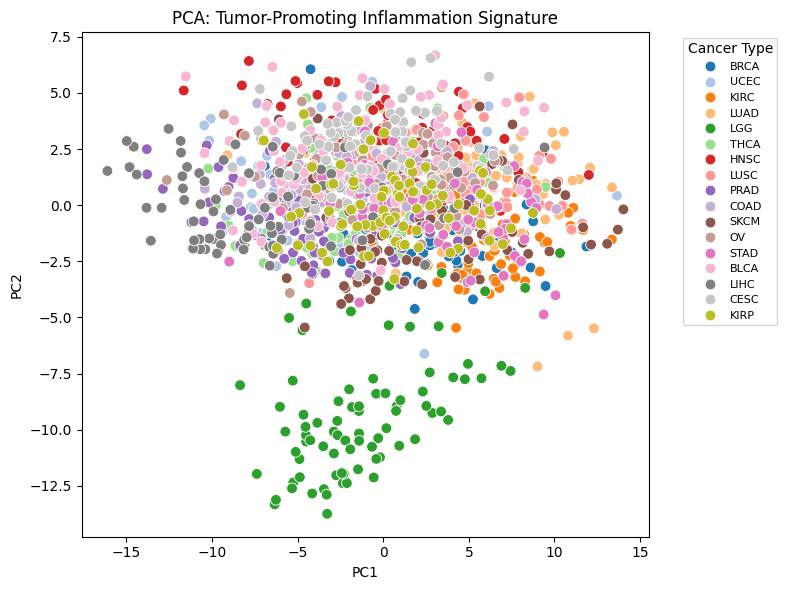

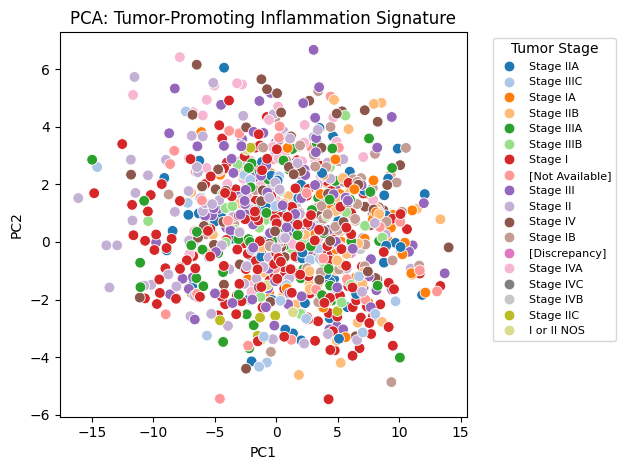

In [5]:
# reading in the hallmarks data s
hallmarks_data = pd.read_table(
    r"C:\Users\ogeik\OneDrive\Desktop\BME 2315\Module-4-Cancer\data\Menyhart_JPA_CancerHallmarks_core.txt", 
    #r"C:\Users\kidus\OneDrive\Desktop\Computational BME\Module 04\Module-4-Cancer\data\Menyhart_JPA_CancerHallmarks_core.txt",
    header=None,
    index_col=0
)

# creating a list of genes associated with the "TUMOR-PROMOTING INFLAMMATION" hallmark
desired_gene_list = list(
    hallmarks_data.loc["TUMOR-PROMOTING INFLAMMATION"].dropna()
)
# reading in the gene expression data and metadata for the validation set
data = pd.read_csv(
    r"C:\Users\ogeik\OneDrive\Desktop\BME 2315\Module-4-Cancer\data\VALIDATION_SET_GSE62944_subsample_log2TPM.csv", 
    #r"C:\Users\kidus\OneDrive\Desktop\Computational BME\Module 04\Module-4-Cancer\data\VALIDATION_SET_GSE62944_subsample_log2TPM.csv",
    index_col=0
)
# reading in the metadata for the validation set
metadata = pd.read_csv(
    r"C:\Users\ogeik\OneDrive\Desktop\BME 2315\Module-4-Cancer\data\VALIDATION_SET_GSE62944_metadata.csv",
    #r"C:\Users\kidus\OneDrive\Desktop\Computational BME\Module 04\Module-4-Cancer\data\VALIDATION_SET_GSE62944_metadata.csv",
    index_col=0       
)

# filtering the gene expression data to include only the genes in the desired gene list
filtered_genes = [g for g in desired_gene_list if g in data.index]

# creating a new DataFrame with the filtered gene expression data
gene_data = data.loc[filtered_genes]

# transposing the gene expression data so that samples are rows and genes are columns
X = gene_data.T

# ensuring that the index of X is of type string and stripping any leading/trailing whitespace
X.index = X.index.astype(str).str.strip()

# converting all values in X to numeric, coercing errors to NaN, and dropping any columns that are entirely NaN
X = X.apply(pd.to_numeric, errors="coerce")
X = X.dropna(axis=1, how="all")

# performing PCA on the filtered gene expression data
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# creating a DataFrame for the PCA results and joining it with the metadata to include cancer type information
pca_df = pd.DataFrame(
    X_pca,
    index=X.index,
    columns=["PC1", "PC2"]
)
pca_df = pca_df.join(metadata["cancer_type"], how="left")
pca_df = pca_df.join(metadata["ajcc_pathologic_tumor_stage"], how="left")

# visualizing the PCA results with a scatter plot, coloring points by cancer type
plt.figure(figsize=(8,6))
sns.scatterplot(
    x=pca_df["PC1"],
    y=pca_df["PC2"],
    hue=pca_df["cancer_type"],
    palette= "tab20",
    s=60
)
plt.title("PCA: Tumor-Promoting Inflammation Signature")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(
    title="Cancer Type",
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
    fontsize=8
)
plt.tight_layout()
plt.show()
sns.scatterplot(
    x=pca_df["PC1"],
    y=pca_df["PC2"],
    hue=pca_df["ajcc_pathologic_tumor_stage"],
    palette= "tab20",
    s=60
)
plt.title("PCA: Tumor-Promoting Inflammation Signature")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(
    title="Tumor Stage",
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
    fontsize=8
)
plt.tight_layout()
plt.show()


##  UMAP Analysis (Non-linear method)
Adding onto the PCA analysis conducted

To begin the UMAP analysis, we used the same filtered tumor-promoting inflammation genes from the hallmarks dataset that were used in the PCA. 
We then applied UMAP dimensionality reduction to the subsetted gene expression data and color coded the results by cancer type and tumor 
stage using the metadata.


In [8]:
!pip install umap-learn

c:\Users\kidus\anaconda3\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


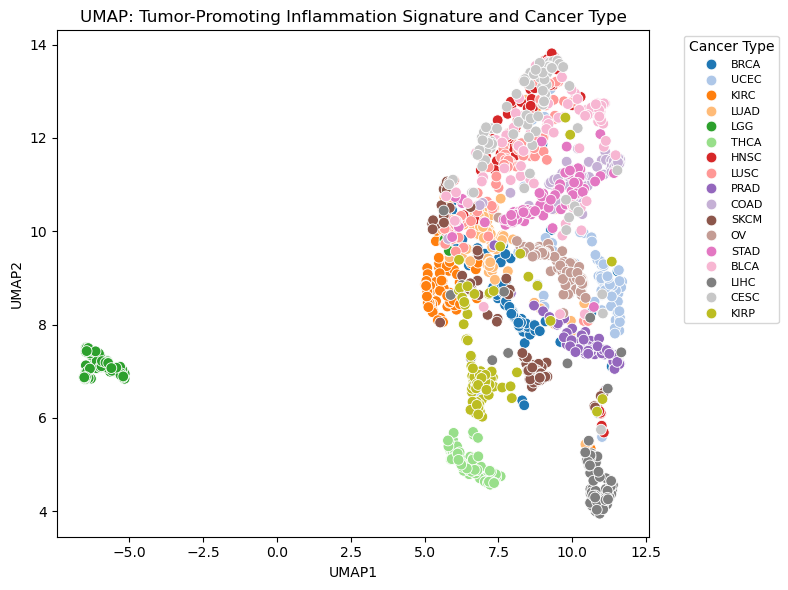

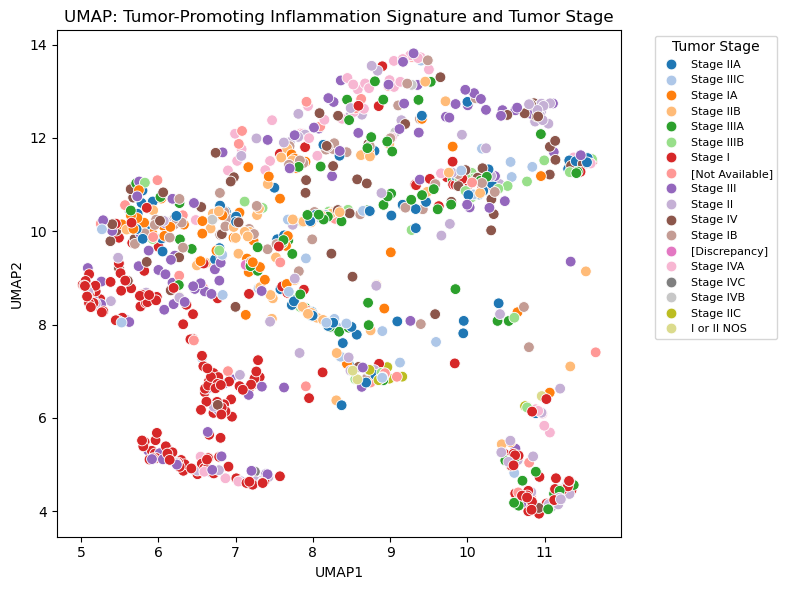

In [ ]:
# UMAP analysis code (based on the fitration already done by intial subsetted data and PCA analysis: -- Analysis on cancer type and tumor stage
import umap # Make sure to run 'pip install umap-learn' in your terminal first!

# Note: 
# Author: Gemini  (04/19/2026)
    # I have used generative AI to try and understand the concepts behind umap analysis method, and how it corresponds with and builds ontop of PCA analysis. 
    # Furthermore, some code block segments and their implemetnation was guided by AI, however, all final interpretation and code finalized was done by the team.

# 1. Instantiate the UMAP model
# n_neighbors: balances local vs global structure (15 is a standard start)
# min_dist: controls how tightly points are packed together (0.1 is standard)
reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42)

# 2. Fit and transform the SAME data X that you used for PCA
X_umap = reducer.fit_transform(X)

# 3. Create a DataFrame for UMAP results
umap_df = pd.DataFrame(
    X_umap, 
    index=X.index, 
    columns=["UMAP1", "UMAP2"]
)

# 4. Join both cancer type and tumor stage metadata columns
umap_df = umap_df.join(metadata["cancer_type"], how="left")
umap_df = umap_df.join(metadata["ajcc_pathologic_tumor_stage"], how="left")

# 5. Visualize UMAP colored by cancer type
# Coloring by cancer type allows us to see if the UMAP clusters
# correspond to biologically distinct tumor origins
plt.figure(figsize=(8,6))
sns.scatterplot(
    x=umap_df["UMAP1"],
    y=umap_df["UMAP2"],
    hue=umap_df["cancer_type"],
    palette="tab20",
    s=60
)
plt.title("UMAP: Tumor-Promoting Inflammation Signature and Cancer Type")
plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.legend(
    title="Cancer Type",
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
    fontsize=8
)
plt.tight_layout()
plt.show()

# 6. Visualize UMAP colored by tumor stage
# Coloring by tumor stage on the same UMAP embedding allows us to check
# whether the clusters identified above also align with disease progression
plt.figure(figsize=(8,6))
sns.scatterplot(
    x=umap_df["UMAP1"],
    y=umap_df["UMAP2"],
    hue=umap_df["ajcc_pathologic_tumor_stage"],
    palette="tab20",
    s=60
)
plt.title("UMAP: Tumor-Promoting Inflammation Signature and Tumor Stage")
plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.legend(
    title="Tumor Stage",
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
    fontsize=8
)
plt.tight_layout()
plt.show()

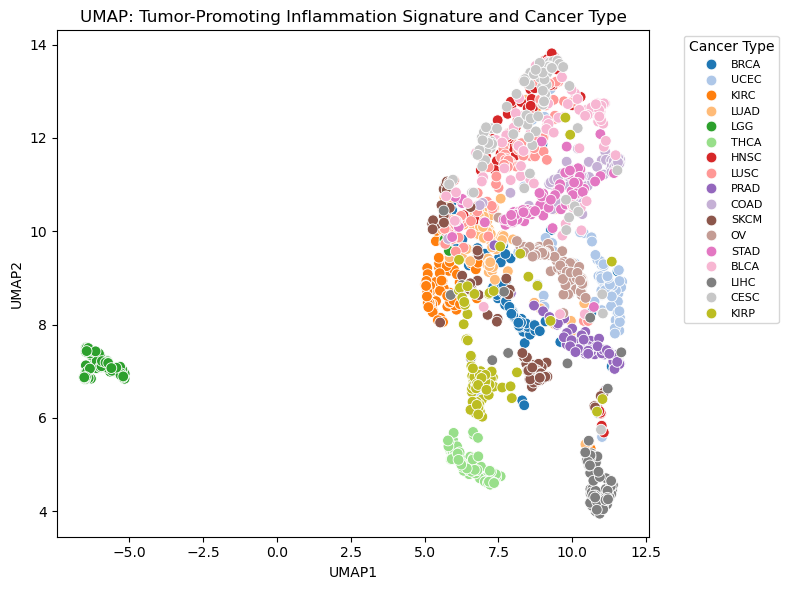

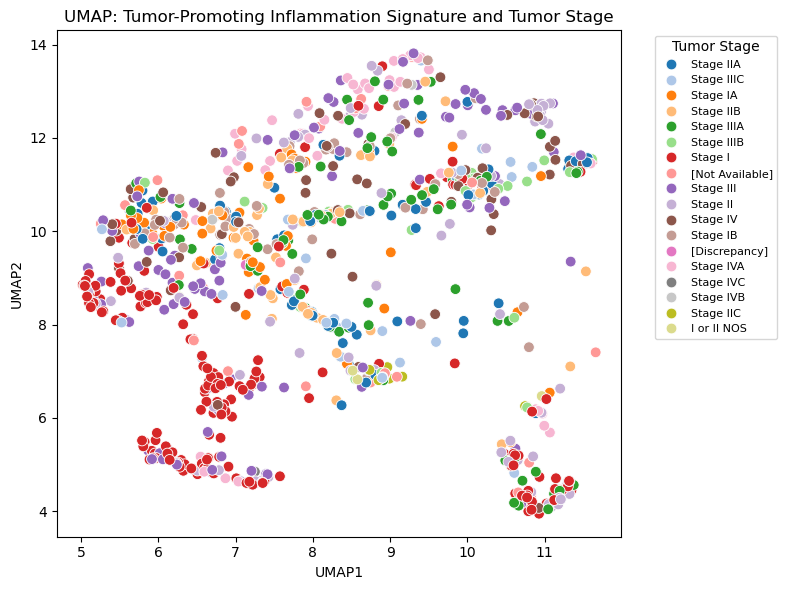

### Methods
The machine learning technique I am using is: Classification for Cancer types and Regression for Tumor Stage

- Classification is a supervised machine learning method used when the target variable is categorical. Since our data is labeled with known 
cancer types, we will use classification to predict cancer type from tumor-promoting inflammation gene expression levels. The data will be 
split into training and testing sets to evaluate performance.

- Regression is a supervised machine learning method used when the target variable is a continuous numerical value. We will map tumor stages (Stage I through Stage IV) to numeric values (1 through 4) and use regression to test whether inflammation gene expression levels linearly increase with tumor stage.

*What is this method optimizing? How does the model decide it is "good enough"?*

- For classification, the model optimizes by learning patterns in the training data that  best separate the categories. It is considered good enough when it  accurately predicts cancer type on the unseen test set at a rate meaningfully above random chance.

- For regression, the model optimizes by minimizing the difference between predicted and actual stage values. Performance is evaluated using the R² score (the coefficent of determination) to analyze the linear relationship between inflammation gene expression and tumor stage, where a value close to 1 indicates a strong positive relationshiop; value closer to 0 indicates no linear relationship; and value closer to -1 indicates negative linear relationship.  

### Analysis
*(Describe how you analyzed the data. This is where you should intersperse your Python code so that anyone reading this can run your code to perform the analysis that you did, generate your figures, etc.)*

## Verify and validate your analysis: 
*Pick a SPECIFIC metric to determine how well your model is performing and describe how it works here.*

*(Describe how you checked to see that your analysis gave you an answer that you believe (verify). Describe how your determined if your analysis gave you an answer that is supported by other evidence (e.g., a published paper).*

## Conclusions and Ethical Implications: 
*(Think about the answer your analysis generated, draw conclusions related to your overarching question, and discuss the ethical implications of your conclusions.*

## Limitations and Future Work: 
*(Think about the answer your analysis generated, draw conclusions related to your overarching question, and discuss the ethical implications of your conclusions.*

## NOTES FROM YOUR TEAM: 
*This is where our team is taking notes and recording activity.*

## QUESTIONS FOR YOUR TA: 
*These are questions we have for our TA.*